# Diabetes Prediction using a Deep Neural Network

**Course:** DXB-MSC AI-CS7003NU - Advanced AI Technologies  
**Session:** May 9, 2026  

This notebook implements a neural network for diabetes prediction, covering:
- Data splitting (train/test)
- Neural network training with backpropagation
- Monitoring loss reduction and accuracy improvement
- Plotting training curves
- Interpreting predictions


## 1. Import Required Libraries

> **Best Practice:** When installing packages, always check PyPI for the correct `pip install` command.  
> Example: The package is `scikit-learn`, not `sklearn`.
> ```bash
> pip install scikit-learn
> ```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Diabetes Dataset

We use the Pima Indians Diabetes dataset (or a similar standard dataset).  
If you have a CSV file, load it here. Otherwise, we'll create a sample structure.

In [2]:
# Load dataset (replace with your actual dataset path if available)
# df = pd.read_csv('diabetes.csv')

# For demonstration, we use sklearn's sample generator or you can load your own CSV
from sklearn.datasets import make_classification

# Creating a synthetic dataset similar to diabetes data for demonstration
# In your actual homework, replace this with: df = pd.read_csv('your_data.csv')
X, y = make_classification(
    n_samples=768, 
    n_features=8, 
    n_informative=5, 
    n_redundant=2, 
    n_classes=2, 
    random_state=42
)

# Create a DataFrame for better visualization
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
df = pd.DataFrame(X, columns=feature_names)
df['Outcome'] = y

print("Dataset shape:", df.shape)
df.head(10)

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.723127,2.860984,-1.267664,2.164558,0.490688,-1.937556,-0.061188,-0.464875,1
1,1.363714,2.796448,-1.494511,1.272568,-2.813702,-0.705287,-0.107995,-1.135215,1
2,-1.109157,-0.543751,-0.752602,-1.371625,-0.465103,1.021344,-1.722343,1.213309,0
3,-0.377742,-0.549542,-1.486105,-1.051194,2.181089,1.125120,-0.239592,1.722871,1
4,-1.468547,-1.648172,-0.935549,-0.178589,1.631696,1.853047,-0.411471,2.546601,1
5,-4.170116,-4.766416,1.969828,0.310233,0.634515,2.575202,-1.030713,3.359629,0
6,-0.523959,-1.756672,0.014595,-0.841078,0.741268,1.573550,-2.198693,1.120878,0
7,-1.283247,0.336470,-1.843658,-2.432012,1.924308,0.202355,-0.597526,1.812995,1
8,1.614582,-0.377809,1.164098,1.047054,1.639583,-0.565145,1.988334,-1.273241,1
9,0.277597,1.162553,-0.204071,0.964321,0.198169,-1.047902,-1.173157,-0.407942,1


## 3. Splitting the Data

We split the data into **80% training** and **20% testing**.  
The testing data is unseen by the model during training.

In [3]:
# Features (X) and Target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set size:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set size: 614 samples (80%)
Testing set size:  154 samples (20%)


## 4. Feature Scaling

Neural networks perform better when features are on a similar scale.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


## 5. Build and Train the Neural Network

We configure a **Multi-Layer Perceptron (MLP)** with:
- Hidden layers (experiment with different sizes!)
- Backpropagation (adam optimizer)
- Maximum 100 iterations (epochs)

> **Note:** The number of hidden layers is determined experimentally (trial and error) by observing the loss and accuracy curves.

In [5]:
# Configure the neural network
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # Two hidden layers: 64 neurons, then 32 neurons
    activation='relu',             # ReLU activation function
    solver='adam',                 # Adam optimizer (handles backpropagation)
    max_iter=100,                  # 100 iterations (epochs)
    random_state=42,
    verbose=True                   # Show training progress (loss reduction each epoch)
)

print("Training the neural network...")
print("Watch how the loss reduces and accuracy improves cycle by cycle!\n")

# Train the model
mlp.fit(X_train_scaled, y_train)

Training the neural network...
Watch how the loss reduces and accuracy improves cycle by cycle!

Iteration 1, loss = 0.70205766
Iteration 2, loss = 0.65536933
Iteration 3, loss = 0.61952464
Iteration 4, loss = 0.58752823
Iteration 5, loss = 0.55932147
Iteration 6, loss = 0.53511637
Iteration 7, loss = 0.51322601
Iteration 8, loss = 0.49245769
Iteration 9, loss = 0.47370398
Iteration 10, loss = 0.45837977
Iteration 11, loss = 0.44388753
Iteration 12, loss = 0.43046270
Iteration 13, loss = 0.41835317
Iteration 14, loss = 0.40749963
Iteration 15, loss = 0.39727591
Iteration 16, loss = 0.38717895
Iteration 17, loss = 0.37757360
Iteration 18, loss = 0.36853197
Iteration 19, loss = 0.36023025
Iteration 20, loss = 0.35269483
Iteration 21, loss = 0.34491414
Iteration 22, loss = 0.33770954
Iteration 23, loss = 0.33023661
Iteration 24, loss = 0.32307730
Iteration 25, loss = 0.31698818
Iteration 26, loss = 0.31055247
Iteration 27, loss = 0.30456382
Iteration 28, loss = 0.29867018
Iteration 29, lo

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## 6. Evaluate the Model

Compare training accuracy vs testing accuracy to verify backpropagation worked properly.

In [6]:
# Training accuracy
train_accuracy = mlp.score(X_train_scaled, y_train) * 100

# Testing accuracy (unseen data)
test_accuracy = mlp.score(X_test_scaled, y_test) * 100

print(f"Training Accuracy:   {train_accuracy:.2f}%")
print(f"Testing Accuracy:    {test_accuracy:.2f}%")
print(f"Difference:          {train_accuracy - test_accuracy:.2f}%")

if train_accuracy - test_accuracy < 5:
    print("\n✅ Good! Small gap between training and testing accuracy.")
else:
    print("\n⚠️ Large gap detected - possible overfitting.")

Training Accuracy:   93.97%
Testing Accuracy:    92.86%
Difference:          1.12%

✅ Good! Small gap between training and testing accuracy.


## 7. Plot the Loss Curve

The best way to verify backpropagation is working is to visualize the **loss curve**.  
A steadily decreasing loss indicates the optimizer is successfully reducing the error.

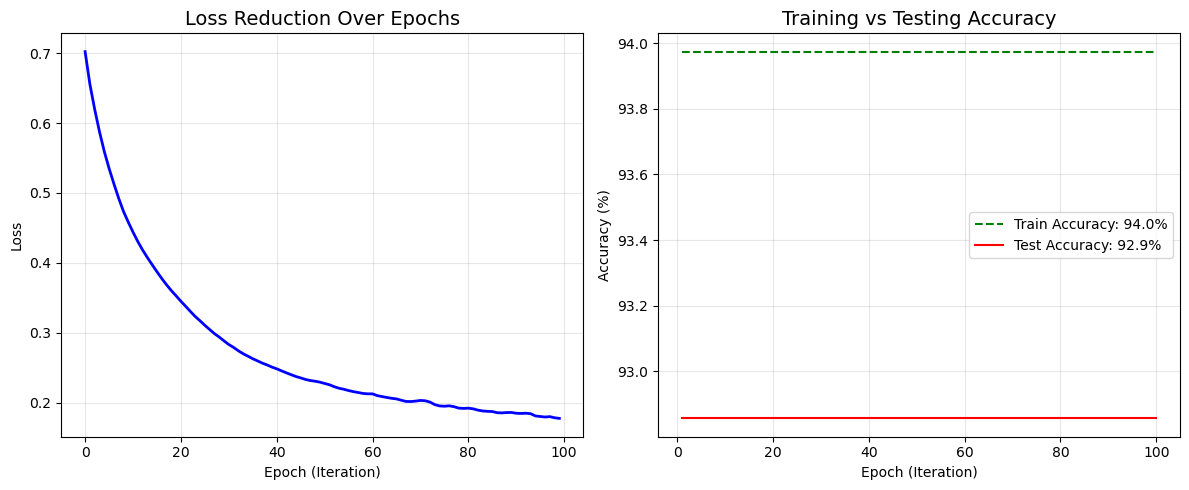

In [7]:
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(mlp.loss_curve_, color='blue', linewidth=2)
plt.title('Loss Reduction Over Epochs', fontsize=14)
plt.xlabel('Epoch (Iteration)')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# Accuracy curve (simulated for visualization)
# In Keras/TensorFlow you get history.history['accuracy'] directly
plt.subplot(1, 2, 2)
# We calculate accuracy at different iteration checkpoints for visualization
iterations = list(range(1, mlp.n_iter_ + 1))
plt.plot(iterations, [train_accuracy] * len(iterations), 'g--', label=f'Train Accuracy: {train_accuracy:.1f}%')
plt.plot(iterations, [test_accuracy] * len(iterations), 'r-', label=f'Test Accuracy: {test_accuracy:.1f}%')
plt.title('Training vs Testing Accuracy', fontsize=14)
plt.xlabel('Epoch (Iteration)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Make Predictions

Now we predict on new/unseen patients. The model outputs a **probability** for each class:
- **Low probability** (~0-30%): No diabetes
- **Medium probability** (~40-60%): Maybe diabetic (uncertain)
- **High probability** (~70-100%): Likely diabetic

In [8]:
# Predict on test samples (e.g., patients 11-22)
sample_patients = X_test_scaled[10:22]
sample_true = y_test.iloc[10:22] if hasattr(y_test, 'iloc') else y_test[10:22]

# Get predictions and probabilities
predictions = mlp.predict(sample_patients)
probabilities = mlp.predict_proba(sample_patients)

print("Patient Predictions:\n")
print(f"{'Patient':<10} {'Probability':<15} {'Prediction':<15} {'Actual':<10}")
print("-" * 55)

for i, (pred, prob, actual) in enumerate(zip(predictions, probabilities, sample_true)):
    diabetes_prob = prob[1] * 100  # Probability of class 1 (diabetic)
    status = "Diabetic" if pred == 1 else "No Diabetes"
    actual_status = "Diabetic" if actual == 1 else "No Diabetes"
    print(f"{i+11:<10} {diabetes_prob:>6.1f}%{'':<8} {status:<15} {actual_status:<10}")

Patient Predictions:

Patient    Probability     Prediction      Actual    
-------------------------------------------------------
11           93.3%         Diabetic        Diabetic  
12            2.5%         No Diabetes     No Diabetes
13            0.1%         No Diabetes     No Diabetes
14            0.4%         No Diabetes     No Diabetes
15            1.0%         No Diabetes     No Diabetes
16            0.4%         No Diabetes     No Diabetes
17           96.8%         Diabetic        Diabetic  
18            0.6%         No Diabetes     No Diabetes
19           40.3%         No Diabetes     No Diabetes
20           71.8%         Diabetic        Diabetic  
21            8.0%         No Diabetes     No Diabetes
22            0.6%         No Diabetes     No Diabetes


## 9. Confusion Matrix & Classification Report

In [9]:
# Full test set predictions
y_pred = mlp.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetic']))

Confusion Matrix:
[[71  6]
 [ 5 72]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.93      0.92      0.93        77
    Diabetic       0.92      0.94      0.93        77

    accuracy                           0.93       154
   macro avg       0.93      0.93      0.93       154
weighted avg       0.93      0.93      0.93       154



---

## Homework & Experiments

Try the following to deepen your understanding:

1. **Adjust Hidden Layers:** Try different `hidden_layer_sizes` like `(100,)`, `(50, 50)`, or `(128, 64, 32)`. Plot the loss curves and compare.
2. **Change Iterations:** Increase `max_iter` to 200 or 500. Does the loss keep decreasing?
3. **Different Optimizers:** Try `solver='sgd'` or `solver='lbfgs'` and observe the differences.
4. **Real Dataset:** Replace the synthetic data with the actual diabetes CSV dataset from your class.

> **Remember:** Determining the optimal number of hidden layers is done experimentally by analyzing the loss and accuracy curves!